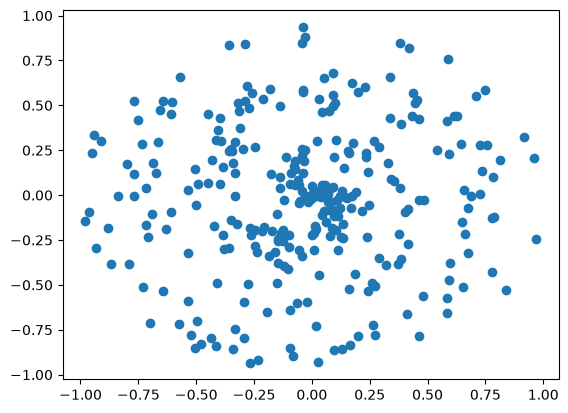

In [1]:
from nnfs.datasets import spiral_data
import numpy as np
import nnfs
nnfs.init()
import matplotlib.pyplot as plt
X,y = spiral_data(samples = 100,classes=3)
plt.scatter(X[:,0],X[:,1])
plt.show()

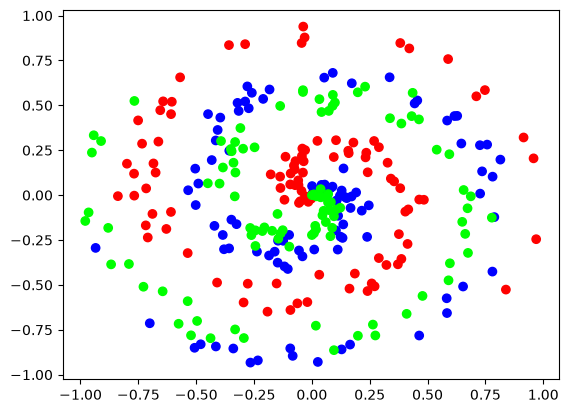

In [2]:
plt.scatter(X[:,0],X[:,1],c=y,cmap="brg")
plt.show()

In [3]:
class Layer_Dense:
    def __init__(self,n_inputs,n_neurons):

        self.weights =0.01*np.random.randn(n_inputs,n_neurons) # this is the transposed version of the w matrix remember that...
        self.biases = np.zeros((1,n_neurons))
    def forward(self,inputs):
        self.output = np.dot(inputs,self.weights) + self.biases

X,y = spiral_data(samples=100,classes = 3)

dense1 = Layer_Dense(2,3)
dense1.forward(X)
dense2=Layer_Dense(3,10)
dense2.forward(dense1.output)

print(dense2.output[:5])


# dense1.output


[[ 0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
   0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [-1.9707636e-07 -1.9534629e-07 -7.2223355e-07  1.1931423e-06
   2.3617797e-06  1.7757268e-06 -1.0806920e-06 -4.2610600e-07
   8.4706056e-07 -2.7544127e-07]
 [-8.7187357e-07 -3.3624269e-06 -3.3759936e-06  4.0463979e-06
  -8.7495886e-07  1.1596194e-06 -5.5061918e-08  1.3776975e-06
   1.6644383e-06  2.7267336e-06]
 [-1.3705726e-06 -5.7138495e-06 -5.3380013e-06  6.1497099e-06
  -3.3161480e-06  6.7524400e-07  7.2341749e-07  2.7249271e-06
   2.2594729e-06  4.9625633e-06]
 [-1.0949345e-06 -2.4371755e-06 -4.1104881e-06  5.9622362e-06
   6.9942757e-06  6.2421968e-06 -3.4468492e-06 -6.0179764e-07
   3.5790076e-06  6.0459382e-07]]


## Activation functions

### ReLU

In [4]:
import numpy as np
inputs = [0,2,-1,3.3,-2.7,1.1,2.2,-100]
output = np.maximum(0,inputs)

In [5]:
class Activation_ReLU:
    def forward(self,inputs):
        self.output = np.maximum(0,inputs) 

In [6]:
X,y = spiral_data(samples=100,classes=3)
dense1 = Layer_Dense(2,3)
dense1.forward(X)
activation1 = Activation_ReLU()
activation1.forward(dense1.output)

print(activation1.output[:5])

[[0.0000000e+00 0.0000000e+00 0.0000000e+00]
 [0.0000000e+00 7.4274081e-05 1.0969164e-04]
 [0.0000000e+00 2.5570381e-04 1.2259498e-04]
 [0.0000000e+00 4.8552279e-04 1.8291285e-05]
 [0.0000000e+00 3.7701402e-04 3.7854823e-04]]


### Softmax activation function

In [7]:
inputs = [[1,2,3,2.5],
     [2,5,-1,2],
     [-1.5,2.7,3.3,-0.8]]
exp_values = np.exp(inputs-np.max(inputs,axis=1,keepdims = True))
probabilities = exp_values/np.sum(exp_values,axis=1,keepdims=True)
print(probabilities)

[[0.06414769 0.17437149 0.47399085 0.28748998]
 [0.04517666 0.90739747 0.00224921 0.04517666]
 [0.00522984 0.34875873 0.63547983 0.0105316 ]]


In [8]:
class Activation_Softmax:
    def forward(self,inputs):
        exp_values = np.exp(inputs-np.max(inputs,axis=1,keepdims = True))
        probabilities = exp_values/np.sum(exp_values,axis=1,keepdims=True)
        self.output = probabilities

In [9]:
# dense1 = Layer_Dense(2,3)
# dense1.forward(X)
# ReLU_dense1 =  Activation_ReLU()
# ReLU_dense1.forward(dense1.output)

# dense2 = Layer_Dense(3,3)
# dense2.forward(ReLU_dense1.output)
# Softmax_dense2 = Activation_Softmax()
# Softmax_dense2.forward(dense2.output)
# print(Softmax_dense2.output[:5])


## Forward Pass without loss function

### making a forward pass for this neural network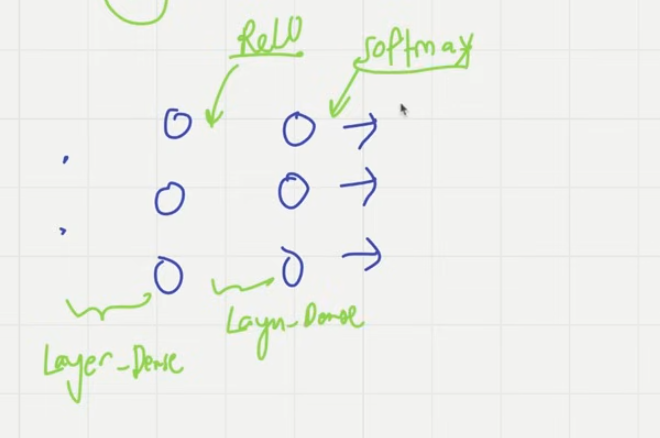

In [10]:
dense1 = Layer_Dense(2,3)
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3,3)
activation2 = Activation_Softmax()

dense1.forward(X)
activation1.forward(dense1.output)
dense2.forward(activation1.output)
activation2.forward(dense2.output)

activation2.output

array([[0.33333334, 0.33333334, 0.33333334],
       [0.33333334, 0.3333335 , 0.33333316],
       [0.33333334, 0.33333433, 0.3333323 ],
       [0.3333333 , 0.3333356 , 0.3333311 ],
       [0.3333334 , 0.33333445, 0.3333321 ],
       [0.3333332 , 0.3333376 , 0.3333292 ],
       [0.3333332 , 0.3333383 , 0.33332855],
       [0.33333355, 0.3333344 , 0.33333212],
       [0.33333355, 0.33333445, 0.333332  ],
       [0.3333333 , 0.33333883, 0.33332786],
       [0.33333293, 0.33334267, 0.3333244 ],
       [0.3333331 , 0.33334216, 0.33332473],
       [0.3333332 , 0.3333419 , 0.3333249 ],
       [0.33333254, 0.3333432 , 0.33332425],
       [0.33333275, 0.33334637, 0.3333209 ],
       [0.3333336 , 0.33333755, 0.3333288 ],
       [0.3333325 , 0.3333476 , 0.3333199 ],
       [0.3333324 , 0.3333472 , 0.33332044],
       [0.3333323 , 0.3333484 , 0.33331928],
       [0.33333218, 0.3333472 , 0.33332068],
       [0.33333218, 0.3333496 , 0.33331826],
       [0.3333325 , 0.3333528 , 0.3333147 ],
       [0.

## Coding loss function

### Cross entropy loss building blocks in python 

In [28]:
softmax_outputs = np.array([[0.7,0.1,0.2],
                            [0.1,0.5,0.4],
                            [0.02,0.9,0.08]])
class_target = [0,1,1]
print(softmax_outputs[[0,1,2],class_target])
# print(softmax_outputs[range(len(softmax_outputs)),class_target]) # can also be written like this 

[0.7 0.5 0.9]


In [29]:
print(-np.log(softmax_outputs[range(len(softmax_outputs)),class_target]))
neg_log= -np.log(softmax_outputs[range(len(softmax_outputs)),class_target])
average_loss = np.mean(neg_log)
print(average_loss)

[0.35667494 0.69314718 0.10536052]
0.38506088005216804


### Extracting relavent prediction in one hot encoding 

In [34]:
y_true_check = np.array([
    [1,0,0],
    [0,1,0],
    [0,1,0]
])
y_pred_clipped_check =np.array([[0.7,0.2,0.1],
                            [0.1,0.5,0.4],
                            [0.02,0.9,0.08]])
softmax_outputs = (y_true_check*y_pred_clipped_check).sum(axis=1)
neg_log = -np.log(softmax_outputs)
print(np.mean(neg_log))
# softmax_outputs

0.38506088005216804


### Implementing loss class and Implementing Categorical Cross Entropy class

In [44]:
class Loss:
    def calculate(self,output,y):
        sample_losses = self.forward(output,y)
        data_loss=np.mean(sample_losses)
        return data_loss

In [45]:
class Loss_CategoricalEntropy(Loss):
    def forward(self,y_pred,y_true):
        samples = len(y_pred)

        y_pred_clipped = np.clip(y_pred,1e-7,1-1e-7)

        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[range(samples) , y_true]
        elif len(y_true.shape) == 2:
            correct_confidences = np.sum(y_pred_clipped*y_true,axis=1)

        return correct_confidences
            

SyntaxError: expected ':' (1127504307.py, line 9)